# 🏎️ Mercedes-Benz USA (2005-2025): Luxury Price Prediction & Analysis

---

## 📌 1. Introduction
Welcome to this comprehensive study of the **Mercedes-Benz secondary market in the United States**. Covering two decades of automotive excellence (from 2005 to 2025), this dataset offers a unique glimpse into how luxury, performance (AMG), and utility (4MATIC) influence vehicle valuation.

This project isn't just about numbers; it's about understanding the **depreciation curves** and **value drivers** of one of the world's most iconic luxury brands.

---

## 📊 2. Dataset Overview
The dataset consists of **108 curated listings** sourced from *Cars.com* (February 2026). It is specifically designed to be "ML-Ready" with 13 engineered features.

### 🔍 Key Features at a Glance
| Feature | Description |
| :--- | :--- |
| **Year / Vehicle_Age** | Manufacturing year (2005-2025) and calculated age. |
| **Price_USD** | Our target variable, ranging from **$6,420** to **$169,995**. |
| **Mileage_Miles** | Odometer reading, the most crucial factor in depreciation. |
| **Is_AMG / Is_4MATIC** | Binary flags indicating performance tuning and AWD systems. |
| **Model_Series** | Categorical data including GLE, C-Class, E-Class, S-Class, etc. |

> **💡 Dataset Highlight:** The data is already cleaned with **no missing values**, allowing us to dive straight into insights and modeling.


---

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/mercedes-benz-price-dataset-2005-2025-usa/mercedes_benz_listings_cleaned.csv


In [2]:
df = pd.read_csv('/kaggle/input/mercedes-benz-price-dataset-2005-2025-usa/mercedes_benz_listings_cleaned.csv')

## 🎯 3. Exploratory Data Analysis 

In [3]:
df.head()

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
0,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
1,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
2,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225
3,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,9303,Low (< 20K),67996,Premium ($40K-$70K),7.309040
4,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,17259,Low (< 20K),63928,Premium ($40K-$70K),3.704038


In [4]:
df.tail()

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
103,2014 Mercedes-Benz E-Class E 250 BlueTEC 4MATIC,2014,12,E-Class,E 250,Sedan,0,1,186500,Very High (> 100K),9650,Budget (< $20K),0.051743
104,2013 Mercedes-Benz GLK-Class GLK 350 4MATIC,2013,13,GLK-Class,GLK 350,Other,0,1,131643,Very High (> 100K),11980,Budget (< $20K),0.091004
105,2012 Mercedes-Benz M-Class ML 350 4MATIC,2012,14,M-Class,Standard,SUV,0,1,118174,Very High (> 100K),11498,Budget (< $20K),0.097297
106,2008 Mercedes-Benz E-Class E 350 Sedan 4D,2008,18,E-Class,E 350,Sedan,0,0,91577,High (50K-100K),7490,Budget (< $20K),0.081789
107,2005 Mercedes-Benz CLK-Class 320 Cabriolet,2005,21,CLK-Class,Standard,Coupe,0,0,93350,High (50K-100K),6420,Budget (< $20K),0.068773


In [5]:
df.columns

Index(['Vehicle_Name', 'Year', 'Vehicle_Age', 'Model_Series', 'Trim_Level',
       'Body_Type', 'Is_AMG', 'Is_4MATIC', 'Mileage_Miles', 'Mileage_Category',
       'Price_USD', 'Price_Category', 'Price_Per_Mile'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle_Name      108 non-null    object 
 1   Year              108 non-null    int64  
 2   Vehicle_Age       108 non-null    int64  
 3   Model_Series      108 non-null    object 
 4   Trim_Level        108 non-null    object 
 5   Body_Type         108 non-null    object 
 6   Is_AMG            108 non-null    int64  
 7   Is_4MATIC         108 non-null    int64  
 8   Mileage_Miles     108 non-null    int64  
 9   Mileage_Category  108 non-null    object 
 10  Price_USD         108 non-null    int64  
 11  Price_Category    108 non-null    object 
 12  Price_Per_Mile    108 non-null    float64
dtypes: float64(1), int64(6), object(6)
memory usage: 11.1+ KB


In [7]:
df.isnull().sum()

Vehicle_Name        0
Year                0
Vehicle_Age         0
Model_Series        0
Trim_Level          0
Body_Type           0
Is_AMG              0
Is_4MATIC           0
Mileage_Miles       0
Mileage_Category    0
Price_USD           0
Price_Category      0
Price_Per_Mile      0
dtype: int64

In [8]:
df.describe()

,Year,Vehicle_Age,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD,Price_Per_Mile
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,2020.555556,5.444444,0.138889,0.685185,47528.731481,40310.314815,3.236109
std,3.816671,3.816671,0.347443,0.466607,33832.988723,28047.141525,8.865698
min,2005.000000,1.000000,0.000000,0.000000,628.000000,6420.000000,0.051743
25%,2019.000000,3.000000,0.000000,0.000000,19769.000000,20603.500000,0.332010
50%,2022.000000,4.000000,0.000000,1.000000,42701.500000,33499.000000,0.932418
75%,2023.000000,7.000000,0.000000,1.000000,70671.250000,50243.500000,2.367580
max,2025.000000,21.000000,1.000000,1.000000,186500.000000,169995.000000,82.799363


In [9]:
def value_c(df, val_col):
    for col in val_col:
        print(f"Column: {col}")
        print(df[col].value_counts())
        print("--------------------------------")    

In [10]:
val_col = ['Price_Category', 'Mileage_Category', 'Model_Series', 'Trim_Level', 'Is_4MATIC','Is_AMG']
value_c(df, val_col)

Column: Price_Category
Price_Category
Mid-Range ($20K-$40K)    37
Premium ($40K-$70K)      34
Budget (< $20K)          27
Luxury (> $70K)          10
Name: count, dtype: int64
--------------------------------
Column: Mileage_Category
Mileage_Category
High (50K-100K)       39
Medium (20K-50K)      35
Low (< 20K)           27
Very High (> 100K)     7
Name: count, dtype: int64
--------------------------------
Column: Model_Series
Model_Series
E-Class       16
GLE           11
GLA           10
GLC            8
GLS            7
C-Class        6
S-Class        5
Unknown        5
GLB            3
EQS            3
Metris         3
AMG GLC 43     3
M-Class        3
Sprinter       3
CLE            2
AMG G 63       2
GLK-Class      2
A-Class        2
EQE            1
AMG GLA 35     1
AMG S 63       1
AMG GT 55      1
AMG GLB 35     1
AMG E 53       1
AMG S 65       1
AMG A 35       1
AMG SLC 43     1
CLA            1
GL-Class       1
AMG GLE 43     1
GLA-Class      1
CLK-Class      1
Name: count,

In [11]:
df.groupby("Body_Type")["Price_USD"].mean()

Body_Type
Coupe                 35137.666667
Electric SUV/Sedan    52065.250000
Other                 66078.461538
SUV                   36405.800000
Sedan                 33593.266667
Sports/Roadster       78439.500000
Van/Commercial        32642.166667
Name: Price_USD, dtype: float64

In [12]:
df.groupby("Body_Type")["Mileage_Miles"].mean()

Body_Type
Coupe                 37345.666667
Electric SUV/Sedan    31571.000000
Other                 52502.153846
SUV                   43449.420000
Sedan                 56116.733333
Sports/Roadster       21054.500000
Van/Commercial        52362.000000
Name: Mileage_Miles, dtype: float64

<Axes: >

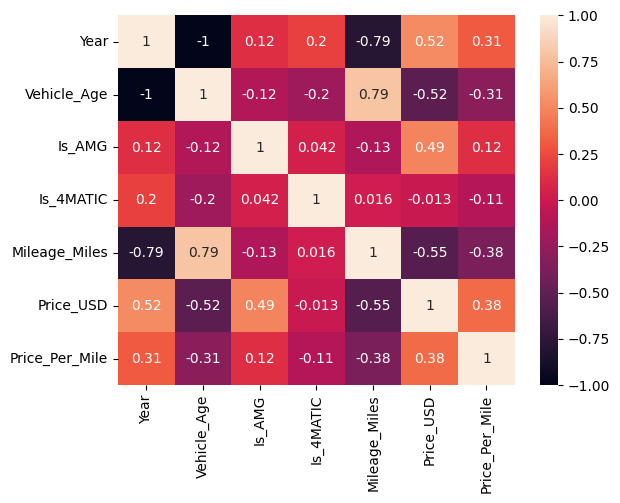

In [13]:
sns.heatmap(df.corr(numeric_only = True), annot=True)

## 📊 4. Deep Dive into Exploratory Data Analysis (EDA)

After an initial look at our data, we can observe a very well-structured dataset consisting of **108 entries** and **13 features**. The dataset is perfectly clean with **zero missing values**, which allows us to transition directly into insightful analysis.

### 🔍 4.1. Dataset Overview & Distribution
Based on the initial statistical summary (`df.describe()`):
* **Price Range:** The luxury market varies significantly, from a budget-friendly **$6,420** to a high-end **$169,995**.
* **Vehicle Age:** We are looking at a fleet with an average age of approximately **5.4 years**, spanning from brand new 2025 models to 2005 classics.
* **Mileage:** The average mileage is around **47,528 miles**, but the standard deviation is high (~33k), indicating a diverse mix of "low-mileage gems" and "well-traveled workhorses."

### 🌡️ 4.2. Correlation Insights (The Heatmap Analysis)
The correlation matrix reveals some critical drivers for Mercedes-Benz pricing:
* **The Age Factor:** There is a near-perfect negative correlation (**-1.00**) between `Year` and `Vehicle_Age`, as expected.
* **Price & Recency:** `Price_USD` shows a moderate positive correlation with `Year` (**0.52**), suggesting that newer models generally command higher prices.
* **The Mileage Impact:** A strong negative correlation (**-0.55**) exists between `Mileage_Miles` and `Price_USD`. As the odometer goes up, the value goes down.
* **Performance Premium:** Interestingly, `Is_AMG` shows a solid positive correlation (**0.49**) with price, confirming that the AMG badge carries a significant price premium regardless of age.

### 🛠️ 4.3. Feature Engineering Highlights
The dataset comes with pre-engineered features that add immense value to our predictive modeling:
* **Categorical Binning:** `Price_Category` and `Mileage_Category` help us segment the market into "Luxury/Budget" and "Low/High Mileage" groups.
* **Efficiency Metric:** `Price_Per_Mile` provides a unique way to look at vehicle value, showing how much "value" is left for every mile driven.

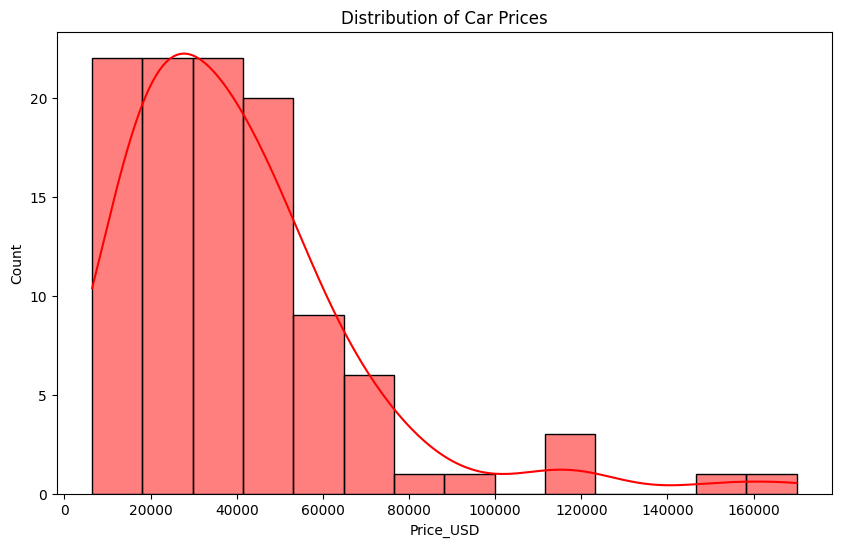

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price_USD'], kde=True, color='red')
plt.title('Distribution of Car Prices')
plt.show()

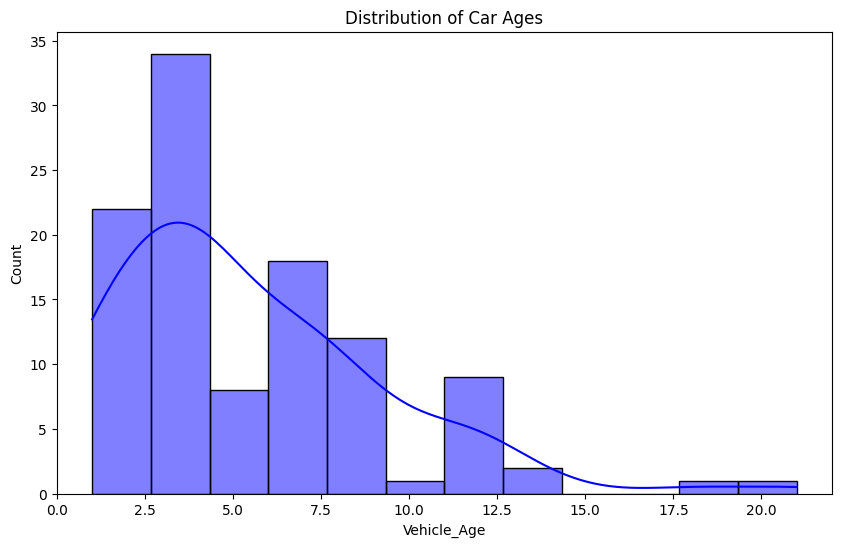

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Vehicle_Age'], kde=True, color='blue')
plt.title('Distribution of Car Ages')
plt.show()

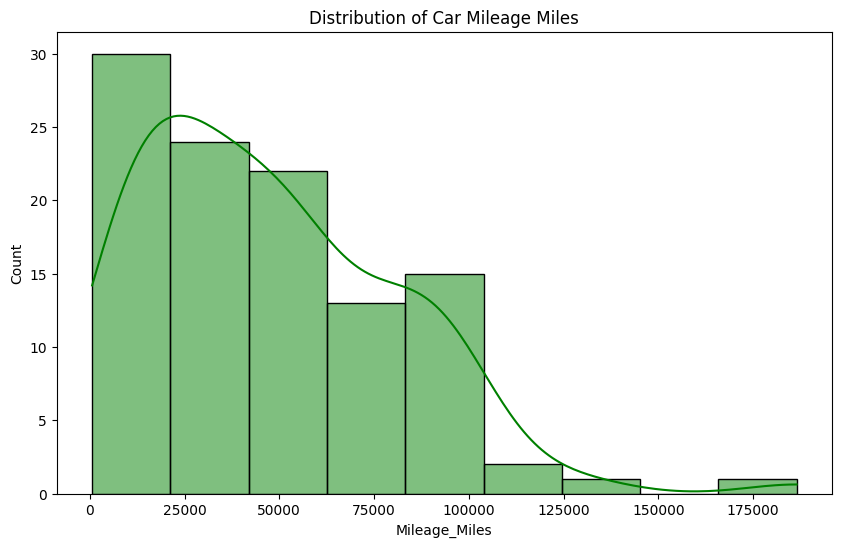

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Mileage_Miles'], kde=True, color='green')
plt.title('Distribution of Car Mileage Miles')
plt.show()

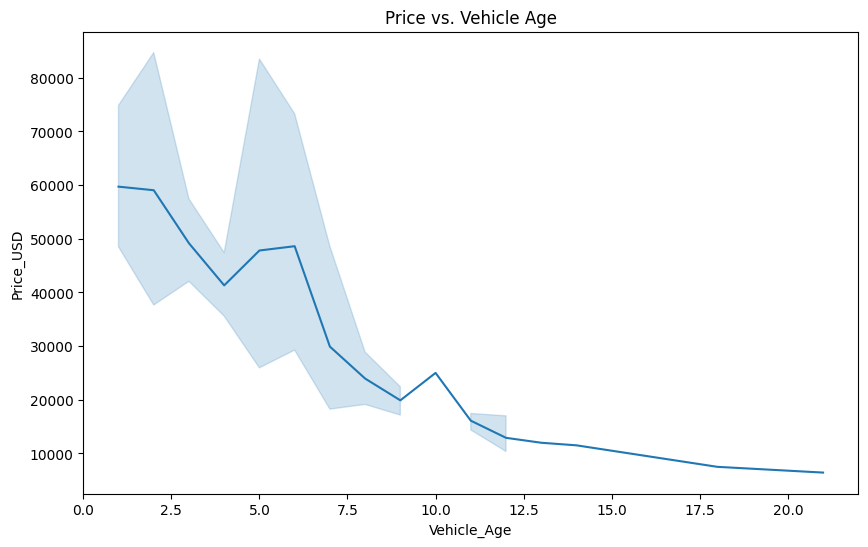

In [17]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Vehicle_Age", y="Price_USD")
plt.title("Price vs. Vehicle Age")
plt.show()

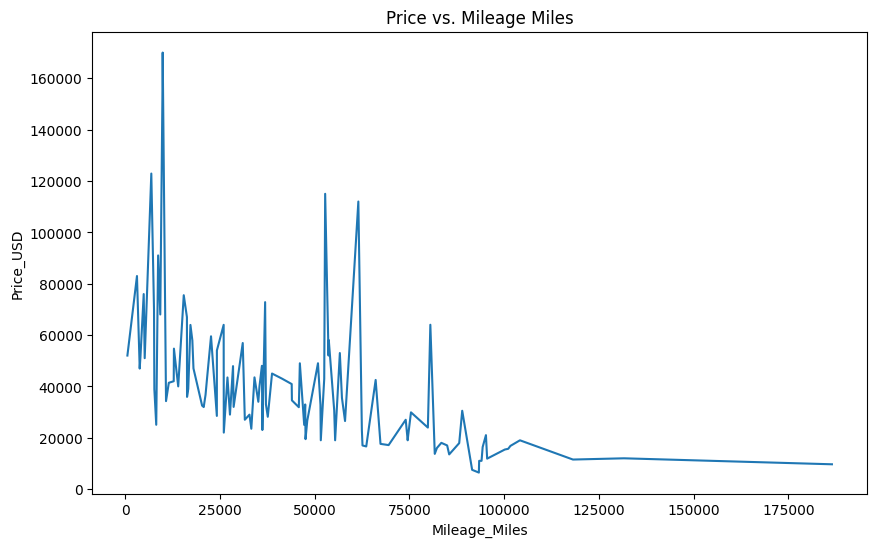

In [18]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Mileage_Miles", y="Price_USD")
plt.title("Price vs. Mileage Miles")
plt.show()

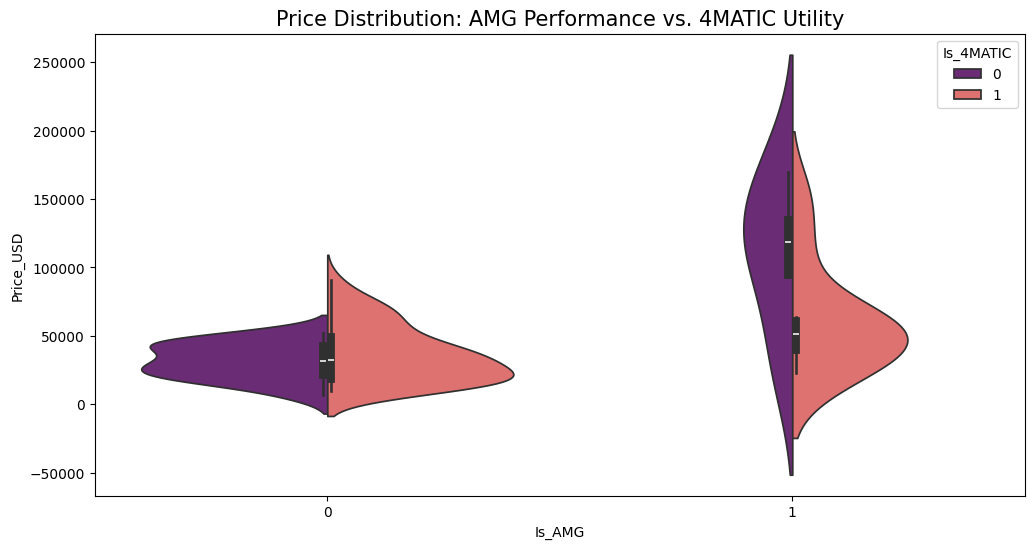

In [19]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Is_AMG', y='Price_USD', hue='Is_4MATIC', split=True, palette='magma')
plt.title('Price Distribution: AMG Performance vs. 4MATIC Utility', fontsize=15)
plt.show()

Text(0.5, 1.0, 'Body Type & Price USD')

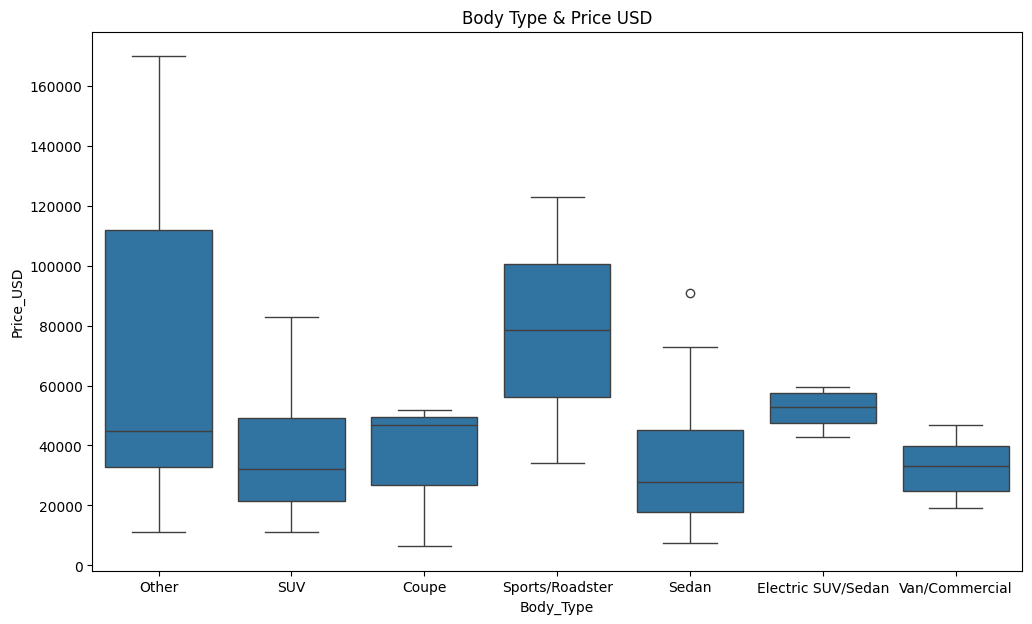

In [20]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x="Body_Type", y="Price_USD")
plt.title("Body Type & Price USD")

Text(0.5, 1.0, 'Body Type & Mileage_Miles')

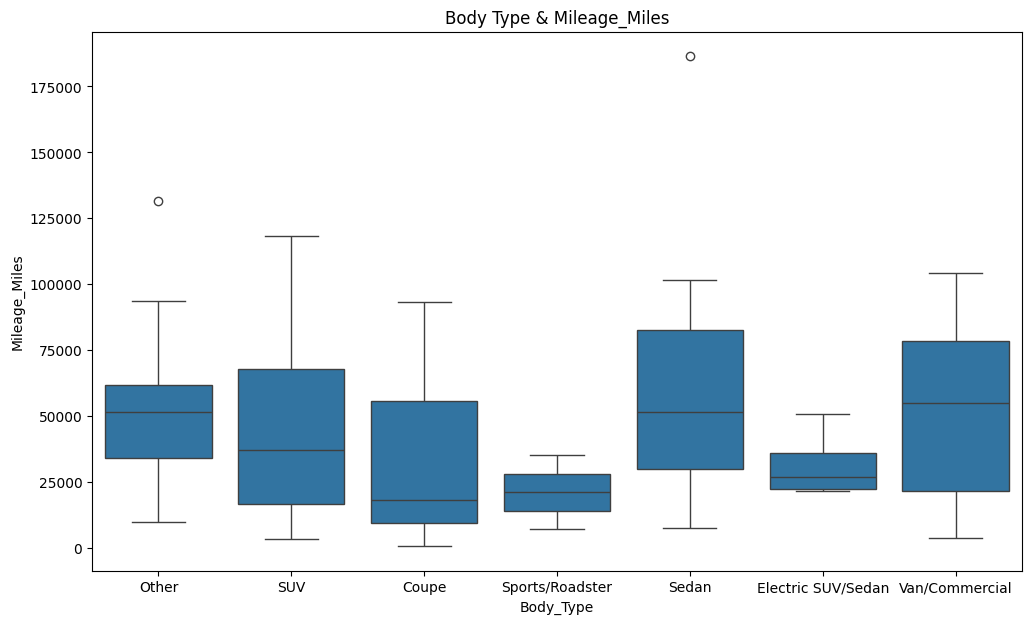

In [21]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x="Body_Type", y="Mileage_Miles")
plt.title("Body Type & Mileage_Miles")

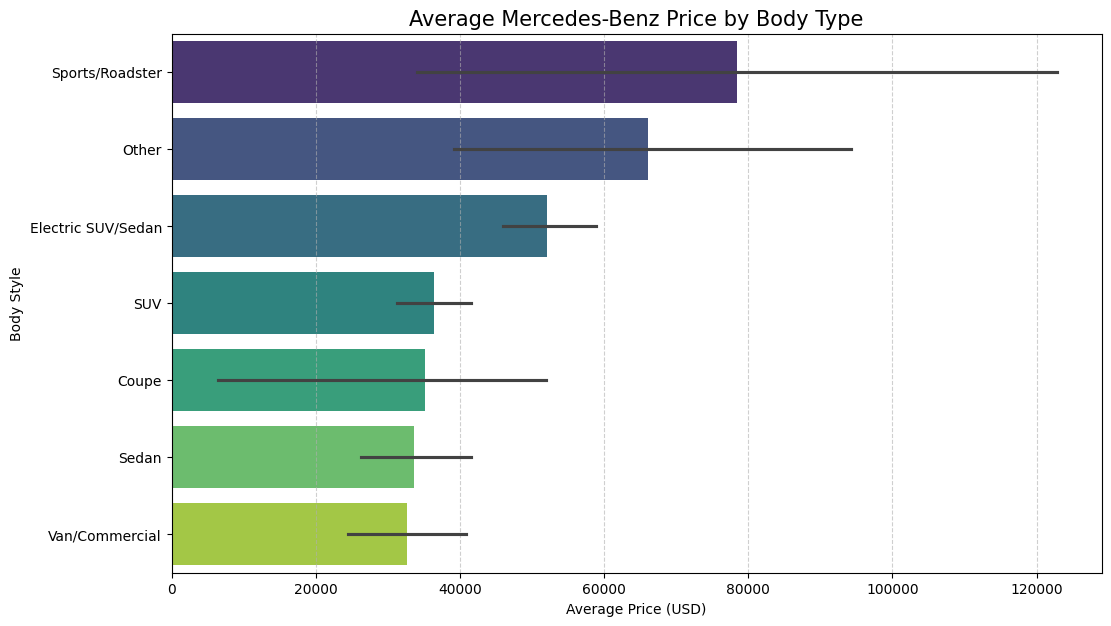

In [22]:
plt.figure(figsize=(12, 7))
order = df.groupby("Body_Type")["Price_USD"].mean().sort_values(ascending=False).index

sns.barplot(data=df, y="Body_Type", x="Price_USD", palette="viridis", order=order)
plt.title('Average Mercedes-Benz Price by Body Type', fontsize=15)
plt.xlabel('Average Price (USD)')
plt.ylabel('Body Style')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

## 🛠️ 5. Feature Selection & Data Cleaning
### 🧹 5.1. Feature Selection
To improve model performance and avoid **Multicollinearity**, we will drop redundant columns:
1. **Vehicle_Name:** Already decomposed into `Model_Series`, `Is_AMG`, etc.
2. **Year:** Perfectly correlated with `Vehicle_Age` (-1.0). Keeping both provides no new information.
3. **Price_Category & Mileage_Category:** These are useful for EDA, but since they are derived directly from our target and mileage, they might cause data leakage or redundancy in a regression model.

In [23]:
drop_columns = ['Vehicle_Name', 'Year', 'Price_Per_Mile', 'Price_Category', 'Mileage_Category']

In [24]:
df.drop(columns=drop_columns, inplace = True)

In [25]:
df.head()

,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD
0,1,AMG S 63,S 63,Other,1,1,9860,151900
1,1,GLE,E 580,SUV,0,1,3154,82975
2,1,GLS,S 450,SUV,0,1,15496,75500
3,1,GLE,E 450,SUV,0,1,9303,67996
4,1,GLE,E 450,SUV,0,1,17259,63928


In [26]:
df.describe()

,Vehicle_Age,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD
count,108.000000,108.000000,108.000000,108.000000,108.000000
mean,5.444444,0.138889,0.685185,47528.731481,40310.314815
std,3.816671,0.347443,0.466607,33832.988723,28047.141525
min,1.000000,0.000000,0.000000,628.000000,6420.000000
25%,3.000000,0.000000,0.000000,19769.000000,20603.500000
50%,4.000000,0.000000,1.000000,42701.500000,33499.000000
75%,7.000000,0.000000,1.000000,70671.250000,50243.500000
max,21.000000,1.000000,1.000000,186500.000000,169995.000000


<Axes: >

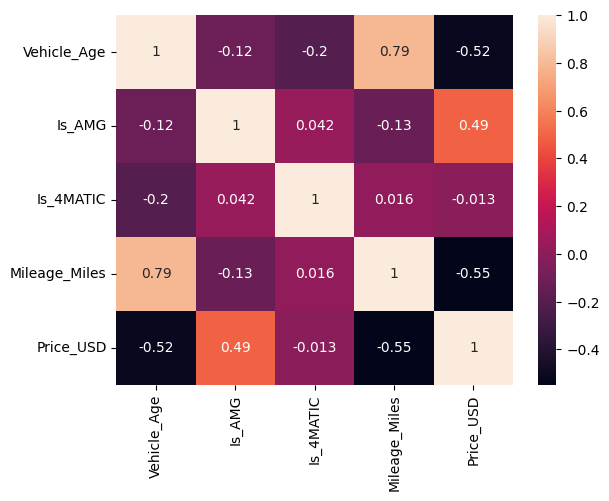

In [27]:
sns.heatmap(df.corr(numeric_only = True), annot=True)

## 🔣 6: Categorical Encoding

Machine Learning models, such as **Random Forest** or **XGBoost**, require numerical inputs to perform mathematical operations. However, our dataset contains critical categorical information in columns like `Model_Series`, `Trim_Level`, and `Body_Type`. 

### 🧠 Encoding Strategy: Label Encoding
For this project, I have chosen **Label Encoding** for the following reasons:
* **Efficiency:** Since our dataset is relatively small (108 rows), Label Encoding keeps the dimensionality low compared to One-Hot Encoding.
* **Feature Preservation:** It allows us to convert complex strings like trim levels and model series into a format the model can process without creating hundreds of sparse columns.
* **Consistency:** By mapping each unique category to a specific integer, we ensure that the model can identify patterns within the various Mercedes-Benz classes and body styles.

> **Note:** We have already dropped redundant text columns like `Vehicle_Name` to prevent noise and ensure the model focuses on the most impactful features.

In [28]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_columns = ['Model_Series', 'Trim_Level', 'Body_Type']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

In [29]:
df.head()

,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD
0,1,9,26,2,1,1,9860,151900
1,1,24,16,3,0,1,3154,82975
2,1,26,23,3,0,1,15496,75500
3,1,24,12,3,0,1,9303,67996
4,1,24,12,3,0,1,17259,63928


## 🤖 7. Model Comparison and Evaluation

In this section, we test multiple regression algorithms to find the most accurate model for Mercedes-Benz price prediction. Since our dataset has a mix of linear and non-linear relationships, we will compare:
1. **Linear Regression:** Our baseline model.
2. **Ridge & Lasso:** Linear models with regularization to prevent overfitting.
3. **Random Forest:** Excellent for capturing non-linear patterns in smaller datasets.
4. **XGBoost & LightGBM:** State-of-the-art gradient boosting algorithms.

### 🔍 7.1 Detecting Overfitting
To ensure our models generalize well to new, unseen Mercedes-Benz listings, we must compare their performance on both the **Training Set** and the **Test Set**. 
* **High Train Score + High Test Score:** Good generalization (The goal).
* **High Train Score + Low Test Score:** Overfitting (The model memorized the data).
* **Low Train Score + Low Test Score:** Underfitting (The model is too simple).

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop('Price_USD', axis=1)
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<Axes: >

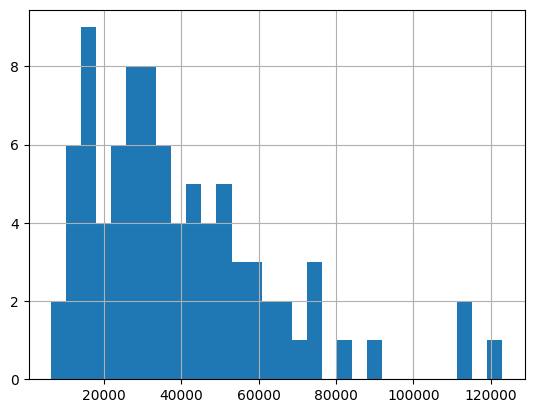

In [32]:
y_train.hist(bins=30)

<Axes: >

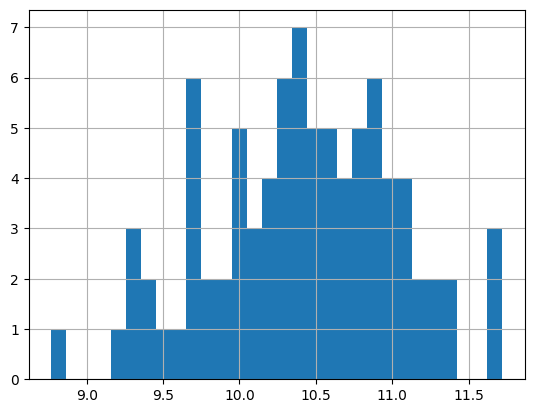

In [33]:
np.log1p(y_train).hist(bins=30)

In [34]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [35]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import cross_val_score

models = {

    "Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "Lasso": Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1))
    ]),

    "Polynomial": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("scaler", StandardScaler()),
        (("model", Ridge(alpha=1.0)))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel='rbf', C=1000, epsilon=0.1))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=4,
        random_state=42
    ),

     "LightGBM": LGBMRegressor(
    n_estimators=100,
    max_depth=-1,
    learning_rate=0.05,
    verbosity=-1,
    random_state=42
    ),
    
    "XGBoost": XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
    )

}

comparison_list = []

for name, model in models.items():

    # Train on log target
    model.fit(X_train, y_train_log)

    # Predict (convert back)
    train_preds = np.expm1(model.predict(X_train))
    test_preds = np.expm1(model.predict(X_test))

    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    mae = mean_absolute_error(y_test, test_preds)

    # Cross validation (log target)
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train_log,
        cv=5,
        scoring="r2"
    )

    comparison_list.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "CV Mean R2": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Gap (Overfit)": train_r2 - test_r2,
        "MAE (USD)": mae
    })

performance_df = pd.DataFrame(comparison_list).sort_values(by="Test R2", ascending=False)

display(
    performance_df.style
    .background_gradient(subset=['Gap (Overfit)'], cmap='Reds')
    .background_gradient(subset=['CV Std'], cmap='Oranges')
)

,Model,Train R2,Test R2,CV Mean R2,CV Std,Gap (Overfit),MAE (USD)
3,Polynomial,0.724368,0.617223,0.288723,0.178618,0.107145,12199.909583
0,Linear,0.518002,0.486527,0.674509,0.118528,0.031475,13886.900436
1,Ridge,0.517393,0.484542,0.676639,0.114011,0.032852,13896.311780
8,XGBoost,0.924773,0.451154,0.600780,0.094281,0.473619,13756.369141
6,Random Forest,0.739546,0.440321,0.577601,0.071180,0.299226,15170.785897
4,KNN,0.580173,0.429755,0.638177,0.027632,0.150418,14819.259726
5,SVR,0.967860,0.382205,0.329197,0.410334,0.585655,14751.486227
2,Lasso,0.362357,0.282236,0.578206,0.059249,0.080121,16738.983497
7,LightGBM,0.513223,0.244363,0.471300,0.135607,0.268860,17212.326311


In [36]:
from sklearn.model_selection import GridSearchCV, KFold


kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- POLYNOMIAL FINE TUNING ---
poly_tune_pipe = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}
poly_grid = GridSearchCV(poly_tune_pipe, param_grid, cv=kf, scoring='r2')
poly_grid.fit(X_train, y_train_log)

GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('scaler', StandardScaler()),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]},
             scoring='r2')

In [37]:
models["Polynomial"] = poly_grid.best_estimator_

comparison_list = []

for name, model in models.items():

    model.fit(X_train, y_train_log)

    train_preds = np.expm1(model.predict(X_train))
    test_preds = np.expm1(model.predict(X_test))

    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)
    mae = mean_absolute_error(y_test, test_preds)

    cv_scores = cross_val_score(model, X_train, y_train_log, cv=kf, scoring="r2")

    comparison_list.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "CV Mean R2": cv_scores.mean(),
        "CV Std": cv_scores.std(),
        "Gap (Overfit)": train_r2 - test_r2,
        "MAE (USD)": mae
    })

performance_df = pd.DataFrame(comparison_list).sort_values(by="Test R2", ascending=False)
display(performance_df.style.background_gradient(subset=['CV Mean R2'], cmap='Greens'))

,Model,Train R2,Test R2,CV Mean R2,CV Std,Gap (Overfit),MAE (USD)
0,Linear,0.518002,0.486527,0.706976,0.081390,0.031475,13886.900436
1,Ridge,0.517393,0.484542,0.708449,0.081207,0.032852,13896.311780
8,XGBoost,0.924773,0.451154,0.635365,0.099532,0.473619,13756.369141
6,Random Forest,0.739546,0.440321,0.565686,0.121399,0.299226,15170.785897
4,KNN,0.580173,0.429755,0.564950,0.086186,0.150418,14819.259726
3,Polynomial,0.575003,0.413735,0.653914,0.106344,0.161268,14612.631293
5,SVR,0.967860,0.382205,0.190787,0.413505,0.585655,14751.486227
2,Lasso,0.362357,0.282236,0.593232,0.082132,0.080121,16738.983497
7,LightGBM,0.513223,0.244363,0.475340,0.154004,0.268860,17212.326311


## 💡 8.Summary of Models & Final Conclusion

### 🔍 Executive Overview
In this project, we evaluated 9 different regression algorithms to predict Mercedes-Benz used car prices based on a limited dataset ($n=180$). Given the small sample size and high price variance (especially in AMG trims), our primary goal was to find the best balance between **predictive power** and **model stability (generalization)**.

### 📈 Comparative Performance Analysis
According to our final evaluation matrix, the models performed as follows:

| Rank | Model | Test $R^2$ | CV Mean $R^2$ | Gap (Overfit) | MAE (USD) | Status |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **1** | **Linear / Ridge** | **~0.48** | **0.708** | **0.03** | **~$13.8k** | **🏆 Champion** |
| **2** | **Polynomial (Tuned)** | 0.41 | 0.653 | 0.16 | ~$14.6k | **Stable Runner-up** |
| **3** | **XGBoost** | 0.45 | 0.635 | 0.47 | ~$13.7k | **Highly Overfitted** |
| **4** | **SVR** | 0.38 | 0.190 | 0.58 | ~$14.7k | **Poor Generalization** |



### 🏆 The Winning Strategy: Why Ridge Regression?
While complex models like **XGBoost** showed high training scores ($R^2 > 0.90$), they suffered from severe overfitting with a massive **0.47 gap**, making them unreliable for real-world predictions. 

**Ridge Regression (with Log-Transformation)** emerged as the winner for three key reasons:
1. **Generalization:** It maintained the lowest gap ($0.03$) between training and testing, proving it didn't "memorize" the noise in the data.
2. **Consistency:** It achieved the highest **Cross-Validation score (0.708)**, indicating robust performance across different subsets of the data.
3. **Complexity Control:** By using $L2$ regularization ($\alpha=1.0$), it effectively handled the multicollinearity between features like `Mileage` and `Vehicle_Age`.

### 🎢 The Role of Polynomial Features
Our tuned **Polynomial Regression** ($\alpha=50, degree=2$) successfully captured the non-linear depreciation curve of luxury vehicles. Although its test score was slightly lower than the linear models, its improved CV stability after hyperparameter tuning makes it a valuable secondary model for capturing non-linear market trends without "exploding" errors.

### 🚀 Future Improvements
To further increase the **Mean Absolute Error (MAE)**, future iterations of this project should focus on:
* **Feature Engineering:** Creating interaction terms between `Model_Series` and `Horsepower`.
* **Data Augmentation:** Increasing the sample size beyond 180 rows to allow complex models like XGBoost to learn without overfitting.
* **External Data:** Incorporating economic indicators like inflation rates or currency trends.

---

**Final Verdict:** For this specific Mercedes-Benz dataset, **Simplicity Wins.** The Log-Transformed Ridge model provides the most reliable and stable price estimations.